``````{admonition} Requires optional libraries
:class: warning, dropdown

This notebook requires a working installation of [GPAW](https://wiki.fysik.dtu.dk/gpaw/index.html), used internally to compute the atomic wave functions for the core-loss transitions, and [sympy](https://www.sympy.org/) for the core-loss form factors. The EDX sections additionally need [xraydb](https://github.com/xraypy/XrayDB) for the atomic data (fluorescence yields, emission line energies, absorption coefficients) that turns an ionisation probability into detected X-ray counts. All three are installed by `pip install abtem[gpaw]`. (Before version `1.1.0` this extra was called `core-loss` and did not include `xraydb`.)

`````{tab-set}
````{tab-item} conda

Install GPAW using conda:
```{code-block}
conda install -c conda-forge gpaw
```
````
````{tab-item} pip

Install GPAW using pip:
```{code-block}
pip install gpaw
```
Install the PAW datasets into the folder `<dir>` using this command:
```{code-block}
gpaw install-data <dir>
```
````
`````

See [here](https://wiki.fysik.dtu.dk/gpaw/install.html) for detailed installation instructions.
``````

In [1]:
import abtem
import ase
import matplotlib.pyplot as plt
import numpy as np
from abtem.inelastic.core_loss import SubshellTransitions
from abtem.inelastic.xray import SpecimenAbsorption
from abtem.inelastic.xray_data import emission_lines, fluorescence_yield
from ase.io import read

abtem.config.set({"diagnostics.progress_bar": False});

(tutorials:eels_and_edx)=
# EELS and EDX

The [previous tutorial](tutorials:core_loss) built the **transition potential** describing an atomic ionisation: the shared physics behind both electron energy-loss spectroscopy (EELS) and energy-dispersive X-ray spectroscopy (EDX). This tutorial turns that transition potential into a detected signal, two different ways:

- **EELS** collects the inelastically scattered electron itself, up to some collection angle, and measures how much energy it lost.
- **EDX** collects the X-ray photon emitted afterwards, when the ionised atom relaxes.

The photon carries no information about the scattering angle of the electron that caused it, nor about exactly how far above threshold the ionisation occurred — so where EELS can restrict itself to one collection angle and one narrow energy window, EDX has to add up *every* angle and the *whole* ionisation edge. That difference drives almost everything below: it is why EDX needs a different simulation route, why it converges differently, and why the two are still cheap to compute together in a single pass.

We cover EELS first (a short recap of the standard interface, since the [previous tutorial](tutorials:core_loss) already introduced the underlying transition potentials), then EDX, and finish with a single simulation that produces both.

## EELS: energy-filtered imaging

We reproduce the essential result of the [previous tutorial's](tutorials:core_loss) cross-section calculation, but through the standard interface, `Probe.transition_potential_scan`. The main difference is that all inelastic scattering events are collected into one measurement: when multiple exit planes are specified for the potential, the measurement above each exit plane "collects" all scattering events above it.

By default, *ab*TEM propagates the scattered wave through the remaining slices (**double-channeling**); passing `double_channel=False` uses the cheaper **single-channeling** approximation, which neglects elastic scattering after the inelastic event. Double-channeling is always more accurate, but far more expensive — see the estimate below.

```{seealso}
The PRISM-based algorithm demonstrated later on this page gives up to double-channeling accuracy while scaling like single-channeling {cite}`brown_linear-scaling`.
```

In [2]:
Si_transitions = SubshellTransitions(Z=14, n=1, l=0, xc="PBE", order=1, epsilon=10)

atoms = ase.build.bulk("Si", cubic=True) * (3, 3, 60)
atoms.center(axis=2)

potential = abtem.Potential(atoms, gpts=128, exit_planes=1, slice_thickness=5.43)

probe = abtem.Probe(
    semiangle_cutoff=30, energy=100e3, Cs=-0.053e-3 * 1e10, defocus=-90, C5=50e-3 * 1e10
)

# All atoms in the column under the probe are potential ionisation sites.
sites = atoms[np.linalg.norm(atoms.positions[:, :2], axis=1) < 0.1]

detector = abtem.PixelatedDetector(max_angle=80)
transition_potentials = Si_transitions.get_transition_potentials()

For a potential with roughly $N_a$ ionisation sites per slice, $N_t$ transitions and $N_z$ slices, double-channeling needs $N_a N_t N_z (N_z - 1) / 2$ multislice steps for a single probe position — the $(N_z - 1)/2$ comes from excitations deeper in the specimen having fewer slices left to propagate through. With one site per slice here, that's:

In [3]:
len(potential) * (len(potential) - 1) // 2 * len(Si_transitions)

7080

— small enough to run in a few seconds below, but the quadratic scaling with thickness is why a realistically thick, densely-sampled double-channeling simulation can take a long time.

```{tip}
The double-channel algorithm precomputes the transmission functions and batches the ionisation sites. Passing a larger `scatter_max_batch` (default 1) to `transition_potential_scan` processes several sites per multislice step, trading memory for speed.
```

In [4]:
measurements_single = probe.transition_potential_scan(
    scan=(0, 0),
    potential=potential,
    detectors=detector,
    transition_potentials=transition_potentials,
    sites=sites,
    double_channel=False,
)
measurements_single = measurements_single.compute()

measurements_double = probe.transition_potential_scan(
    scan=(0, 0),
    potential=potential,
    detectors=detector,
    transition_potentials=transition_potentials,
    sites=sites,
)
measurements_double = measurements_double.compute()

We stack the two (discarding the zero'th exit plane, which is the incoming beam) and integrate to three collection angles, as in the previous tutorial.

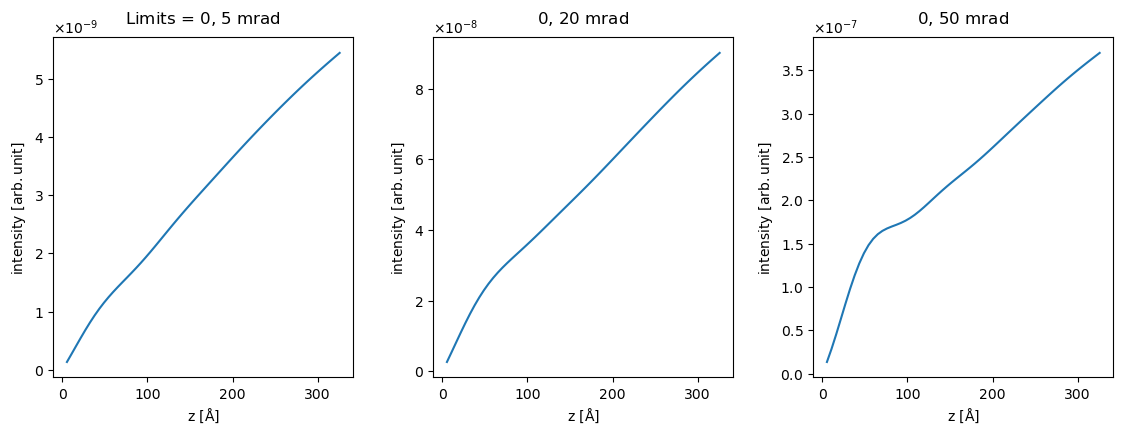

In [5]:
stacked = abtem.stack(
    [measurements_single[1:], measurements_double[1:]],
    axis_metadata=("single channel", "double channel"),
    axis=0,
)

integrated = stacked.integrate_radial(inner=0, outer=(5, 20, 50))
integrated.show(
    overlay=(1,), explode=(0,), figsize=(12, 4), common_scale=False, title=True
);

Single-channeling is monotonically increasing with depth — it is just the cumulative sum of the differential cross-section from the previous tutorial — and approaches double-channeling as the collection angle grows, since a large enough aperture collects the scattered electron regardless of any further elastic scattering it undergoes. At small collection angles the two differ qualitatively, not just in scale: below, double-channeling (top) develops the star-shaped dynamical diffraction contrast expected from further elastic scattering after the inelastic event, while single-channeling (bottom), which stops at the transition potential itself, stays a smooth, featureless disc.

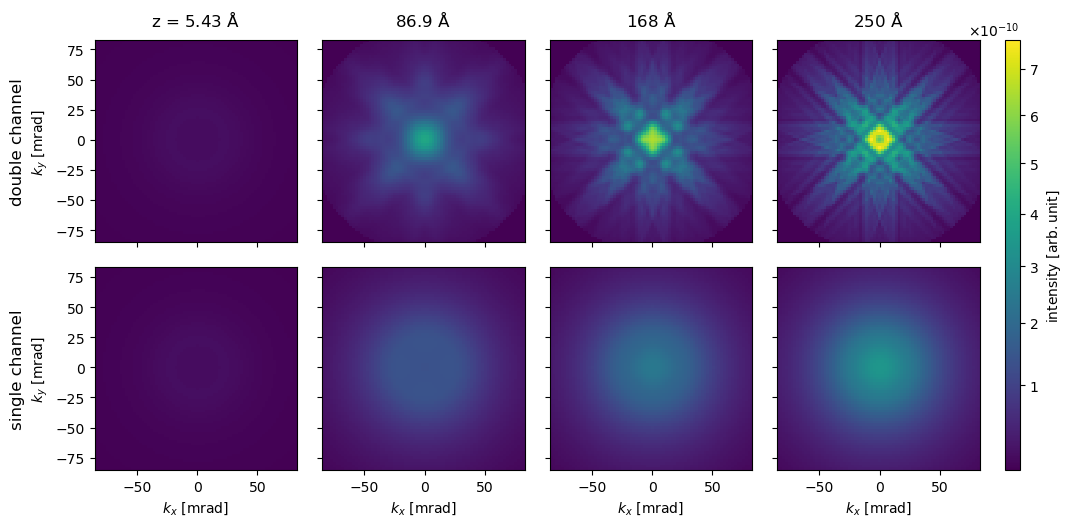

In [6]:
visualization = abtem.array.swapaxes(stacked, 0, 1)[::15, :].show(
    explode=True,
    units="mrad",
    figsize=(12, 5),
    cbar=True,
    common_color_scale=True,
    power=0.8,
)

## EELS: atomic-resolution imaging

We now simulate an energy-filtered STEM image of SrTiO$_3$ on the $\left<100\right>$ zone axis, targeting the *K*-edge of oxygen and the *L*$_{23}$-edge of strontium — the two edges most commonly mapped in this material.

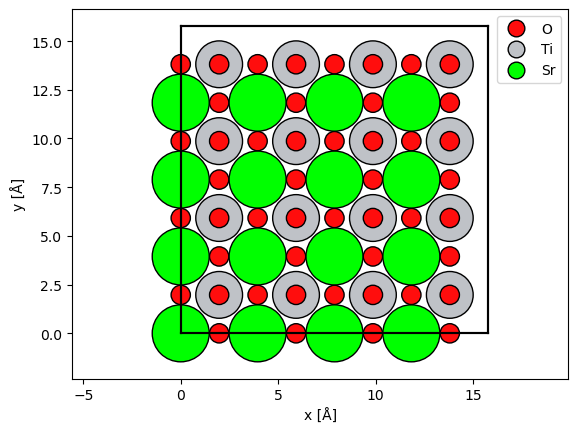

In [7]:
atoms = read("../walkthrough/data/srtio3_100.cif")
slice_thickness = atoms.cell[2, 2] / 2
atoms *= (4, 4, 25)

potential = abtem.Potential(atoms, gpts=256, slice_thickness=slice_thickness, device="cpu")

abtem.show_atoms(atoms, legend=True);

In [8]:
O_transitions = SubshellTransitions(Z=8, n=1, l=0, xc="PBE", order=1, epsilon=10)
Sr_transitions = SubshellTransitions(Z=38, n=2, l=1, xc="PBE", order=1, epsilon=10)

O_transition_potentials = O_transitions.get_transition_potentials(energy=100e3)
O_transition_potentials.grid.match(potential)
O_transition_potentials_array = O_transition_potentials.build()

Sr_transition_potentials = Sr_transitions.get_transition_potentials(energy=100e3)
Sr_transition_potentials.grid.match(potential)
Sr_transition_potentials_array = Sr_transition_potentials.build()

print(f"O K:    {len(O_transition_potentials_array)} transitions")
print(f"Sr L23: {len(Sr_transition_potentials_array)} transitions")

O K:    4 transitions
Sr L23: 27 transitions


As in the previous tutorial, we thin out the strontium transitions with `filter_by_intensity` — most of the intensity is concentrated in a few of them.

In [9]:
filtered_Sr_transition_potentials = Sr_transition_potentials_array.filter_by_intensity(
    threshold=0.95, max_angle=60
)
len(filtered_Sr_transition_potentials)

9

We set up a probe, scan and detector as for a standard STEM simulation.

In [10]:
probe = abtem.Probe(semiangle_cutoff=25, energy=100e3, device="cpu")
probe.grid.match(potential)

scan = abtem.GridScan(
    start=(0, 0), end=(1 / 4, 1 / 4), fractional=True, potential=potential, endpoint=False
)

detector = abtem.FlexibleAnnularDetector(to_cpu=True)

Since both the probe and the transition potentials are localised, we can also discount ionisation sites whose transition potential barely overlaps the probe. Below, a stricter threshold $t$ keeps progressively fewer oxygen sites around a probe placed on the marked column.

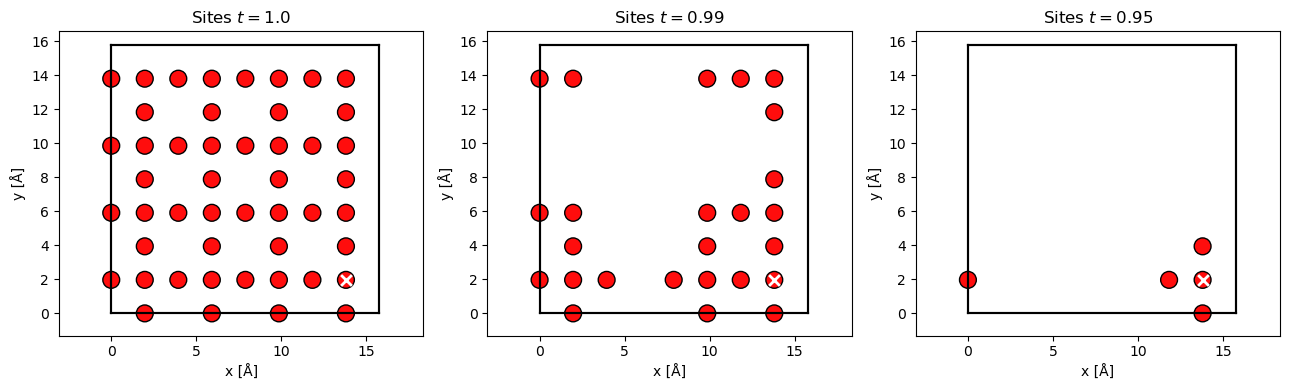

In [11]:
sites_all = atoms[(atoms.numbers == 8) * (atoms.positions[:, 2] < 2)]

position = sites_all[38].position[:2]
waves = probe.build(position).compute(progress_bar=False)

ts = [1.0, 0.99, 0.95]

fig, axes = plt.subplots(1, len(ts), figsize=(13, 4))
for t, ax in zip(ts, axes):
    absolute_threshold = O_transition_potentials_array.absolute_threshold(
        waves, threshold=t
    )
    sites = O_transition_potentials_array.filter_sites(
        waves, sites_all, absolute_threshold
    )
    abtem.show_atoms(sites, ax=ax, title=f"Sites $t={t}$")
    ax.scatter(*position.T, c="w", marker="x", s=60, linewidth=2)

plt.tight_layout()

We run `transition_potential_scan` with single-channeling and a site threshold of $t=0.95$ for both edges. Each scan takes roughly a minute.

In [12]:
import time

t0 = time.time()
O_measurements = probe.transition_potential_scan(
    scan=scan, potential=potential, detectors=detector,
    transition_potentials=O_transition_potentials_array,
    double_channel=False, max_batch=40, threshold=0.95,
)
O_measurements = O_measurements.compute(scheduler="threads", num_workers=6)
eels_only_seconds = time.time() - t0
print(f"EELS-only O K scan: {eels_only_seconds:.0f} s")

Sr_measurements = probe.transition_potential_scan(
    scan=scan, potential=potential, detectors=detector,
    transition_potentials=filtered_Sr_transition_potentials,
    double_channel=False, max_batch=40, threshold=0.95,
)
Sr_measurements = Sr_measurements.compute(scheduler="threads", num_workers=6)

EELS-only O K scan: 75 s


We stack the two, integrate to the collection angle, tile and interpolate onto a fine grid — the standard post-processing for a STEM map.

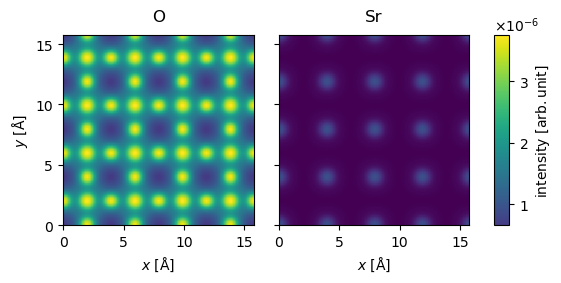

In [13]:
stacked_measurements = abtem.stack((O_measurements, Sr_measurements), ("O", "Sr"))

post_processed_measurements = (
    stacked_measurements.integrate_radial(inner=0, outer=60)
    .tile(repetitions=(4, 4))
    .interpolate(sampling=0.05)
)

visualization = post_processed_measurements.show(
    explode=True, common_color_scale=True, cbar=True
)

The oxygen sublattice is clearly resolved; the strontium columns are visible but much fainter under this shared colour scale, since Sr L$_{23}$'s ionisation cross-section is smaller than O K's at this energy — a real difference between edges, not a simulation artefact, and a reminder that a shared scale across edges of very different strength can visually bury the weaker one. Showing each edge on its own scale (drop `common_color_scale=True`) recovers the character of Fig. 3(c) in [DOI:10.1103/PhysRevB.77.184107](https://doi.org/10.1103/PhysRevB.77.184107) for both.


## EELS: linear-scaling PRISM-EELS

Every scan above runs a full multislice simulation for each probe position, so the cost grows linearly with the number of positions — the same bottleneck that the [PRISM algorithm](tutorials:prism) removes for elastic STEM simulations. Since version `1.1.0`, the PRISM factorisation is also available for core-loss simulations through `SMatrix.transition_potential_scan`, following the linear-scaling algorithm of {cite}`brown_linear-scaling`. The scattering matrix is built once, and the inelastic scattering from each site is evaluated once; only the reduction onto each probe position needs repeating.

In [14]:
s_matrix = abtem.SMatrix(
    potential=potential, energy=100e3, semiangle_cutoff=25,
    interpolation=4, downsample="cutoff", device="cpu",
)

O_measurements_prism = s_matrix.transition_potential_scan(
    transition_potentials=O_transition_potentials_array,
    scan=scan, detectors=detector, double_channel=False, lazy=False,
)

largest deviation: 8.0%


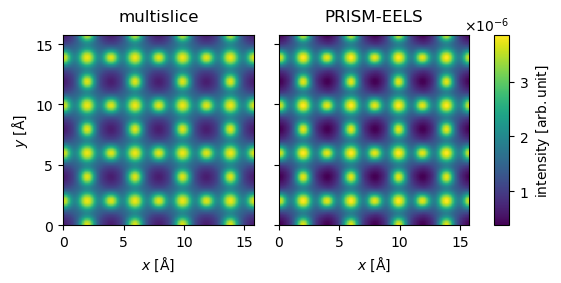

In [15]:
stacked_O = abtem.stack((O_measurements, O_measurements_prism), ("multislice", "PRISM-EELS"))

post_processed_O = (
    stacked_O.integrate_radial(inner=0, outer=60)
    .tile(repetitions=(4, 4))
    .interpolate(sampling=0.05)
)
post_processed_O.show(explode=True, common_color_scale=True, cbar=True);

maps = stacked_O.integrate_radial(inner=0, outer=60).array
print(f"largest deviation: {np.abs(maps[1] - maps[0]).max() / maps[0].max():.1%}")

The two maps agree closely. The remaining difference comes from the PRISM interpolation factor (`interpolation=1` removes it entirely, reproducing `Probe.transition_potential_scan` to floating-point noise, at the cost of the speedup) and from the multislice scan discarding weakly-contributing sites with `threshold=0.95` while the PRISM scan includes all of them.

## EDX: collecting the whole edge and all angles

An EELS spectrometer restricts itself to a collection angle and an energy window because it can — the scattered electron still exists after the event, and both are properties of *that electron*. An emitted X-ray photon is a different object: it carries the energy of the transition but nothing about which final state the electron ended up in, so an X-ray measurement is necessarily summed over **every** final state — every scattering angle and the **whole** continuum energy above threshold, not a narrow window at one $\epsilon$. This isn't an approximation adopted for convenience; restricting either one would describe a different, unphysical measurement.

Two consequences follow directly:

- **Angle**: `Probe.ionization_scan` (and the matching `Waves.ionization_multislice`, `PlaneWave.ionization_multislice`, `SMatrix.ionization_scan`) use the effective-potential route instead of explicit scattered waves. Parseval turns the sum over final states into a real-space integral against an effective local potential built once per slice, with no scattered waves to propagate — exact for a measurement collecting all angles, and much cheaper than the scattered-wave route besides.
- **Energy**: `SubshellTransitions` needs `epsilon` given as an `EnergyIntegral`, not a single value, so that the transition potential is built already integrated over the edge.

We check both effects on a small silicon cell before running the common EDX case.

### Integrating over the edge

The integrand is close to flat just above threshold and decays only slowly, so truncating the integration window loses more than it might look. We compare `EnergyIntegral(start=1, stop=100, ...)` — a 100 eV window, comparable to a typical EELS acquisition range — against one extending to four times the Si K edge energy (1839 eV).

In [16]:
def si_k_ionization(stop, num=8):
    subshell = abtem.SubshellTransitions(
        Z=14, n=1, l=0, epsilon=abtem.EnergyIntegral(start=1.0, stop=stop, num=num)
    )
    transitions = subshell.get_transition_potentials(
        extent=potential.extent, gpts=potential.gpts, energy=100e3
    )
    result = probe.ionization_scan(potential, transitions, scan=scan_point, sites=sites)
    return float(np.asarray(result.compute().array).max())


atoms = ase.build.bulk("Si", cubic=True) * (2, 2, 4)
potential = abtem.Potential(atoms, gpts=64, slice_thickness=1.36, exit_planes=1)
probe = abtem.Probe(energy=100e3, semiangle_cutoff=25)
probe.grid.match(potential)
scan_point = (potential.extent[0] / 2, potential.extent[1] / 2)
sites = atoms[np.linalg.norm(atoms.positions[:, :2] - np.array(scan_point), axis=1) < 0.1]

truncated = si_k_ionization(100.0)
full_edge = si_k_ionization(4 * 1839.0)

print(f"truncated at 100 eV:  {truncated:.3e}")
print(f"full edge (4x E_K):   {full_edge:.3e}")
print(f"fraction captured:    {truncated / full_edge:.1%}")

truncated at 100 eV:  9.935e-06
full edge (4x E_K):   8.700e-05
fraction captured:    11.4%


Even in this small cell, truncating at 100 eV misses most of the signal — consistent with the ~14 % found for a converged setup. `num=8` quadrature nodes is enough for `EnergyIntegral` to converge; doubling it changes the result negligibly.

### Collecting all angles

We now compare the same edge collected within a 30 mrad EELS aperture (`transition_potential_scan` with an `AnnularDetector`) against every angle at once (`ionization_scan`).

In [17]:
subshell = abtem.SubshellTransitions(
    Z=14, n=1, l=0, epsilon=abtem.EnergyIntegral(stop=4 * 1839.0, num=8)
)
transitions = subshell.get_transition_potentials(
    extent=potential.extent, gpts=potential.gpts, energy=100e3
)

all_angles = probe.ionization_scan(potential, transitions, scan=scan_point, sites=sites)
all_angles = float(np.asarray(all_angles.compute().array).max())

within_30mrad = probe.transition_potential_scan(
    potential, transitions, scan=scan_point,
    detectors=abtem.AnnularDetector(inner=0.0, outer=30.0),
    sites=sites,
)
within_30mrad = float(np.asarray(within_30mrad.compute().array).max())

print(f"within 30 mrad: {within_30mrad:.3e}")
print(f"all angles:     {all_angles:.3e}")
print(f"fraction captured: {within_30mrad / all_angles:.1%}")

within 30 mrad: 2.533e-05
all angles:     8.700e-05
fraction captured: 29.1%


A 30 mrad aperture — generous by EELS standards — collects only around a third of the total Si K ionisation at 100 keV, matching the ~33 % reported for a converged setup. Roughly 200 mrad would be needed to reach 99 %. Restricting to any finite aperture is not something an X-ray detector can do even in principle.

### The common case: an EDX map

With both pieces in hand, the EDX workflow is: build a transition potential integrated over the edge, run `ionization_scan`, then convert the result to counts with an `XrayDetector`. Rather than the toy silicon cell above, we rebuild the same SrTiO$_3$ specimen, probe and scan as the atomic-resolution EELS map earlier on this page, so the result is directly comparable — same field of view, same probe, same oxygen K edge, just detected as X-rays instead of scattered electrons.

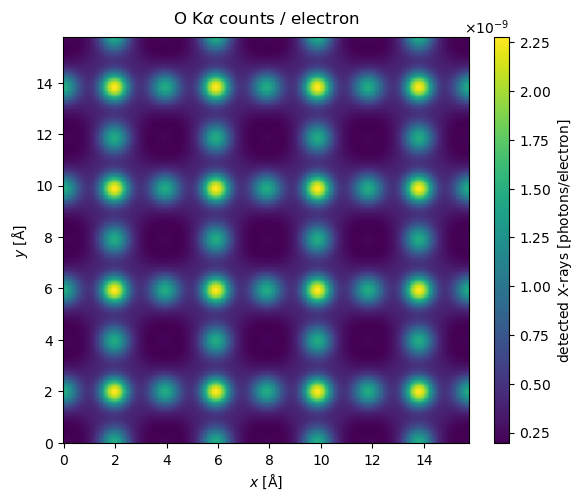

In [18]:
atoms = read("../walkthrough/data/srtio3_100.cif")
slice_thickness = atoms.cell[2, 2] / 2
atoms *= (4, 4, 25)
potential = abtem.Potential(atoms, gpts=256, slice_thickness=slice_thickness, device="cpu")

probe = abtem.Probe(semiangle_cutoff=25, energy=100e3, device="cpu")
probe.grid.match(potential)

scan = abtem.GridScan(
    start=(0, 0), end=(1 / 4, 1 / 4), fractional=True, potential=potential, endpoint=False
)

O_edx_transitions = abtem.SubshellTransitions(
    Z=8, n=1, l=0, xc="PBE", order=1, epsilon=abtem.EnergyIntegral(stop=4 * 543.1, num=8)
)
O_edx_transition_potentials = O_edx_transitions.get_transition_potentials(
    extent=potential.extent, gpts=potential.gpts, energy=100e3
).build()

ionization = probe.ionization_scan(potential, O_edx_transition_potentials, scan=scan)
ionization = ionization.compute(scheduler="threads", num_workers=6)

detector = abtem.XrayDetector.from_sdd(
    solid_angle=0.7,                                      # sr
    window=("Be", 8.0),                                   # um
)
counts = detector.to_counts(ionization, "O", 1, 0)        # photons / electron

edx_map = (
    counts.tile(repetitions=(4, 4))
    .interpolate(sampling=0.05)
)
edx_map.show(cbar=True, title="O K$\\alpha$ counts / electron");

`ionization` is the ionisation probability per incident electron, resolved over the scan and the exit planes — this is what `Probe.transition_potential_scan` would give with an `IonizationDetector` in place of an angular one, just computed the cheap way (a few seconds here, against roughly a minute for the EELS scan on the same specimen). `to_counts` then applies the radiometric chain from the module docstring: fluorescence yield, branching ratio into the selected lines, collected solid angle and detector efficiency.

`XrayDetector.from_sdd` builds the efficiency from a layered detector model (`SDDEfficiency`): the entrance window, contact and dead layer attenuate, and the active layer absorbs. A constant `efficiency=`, or a measured curve wrapped in `TabulatedEfficiency`, both work just as well if you have one.

### Specimen self-absorption

Not modelled above: an X-ray generated deep in the specimen has to travel back out through the rest of it to reach the detector, and softer lines — oxygen K$\alpha$ at 525 eV among them — are attenuated doing so. `SpecimenAbsorption` models this, but it needs the emission depth, which only exists *during* a scan; `to_counts` receives an ionisation measurement already summed over depth, so it has nothing to apply the correction to. Setting `absorption=` on a detector and then calling `to_counts` — as it might be tempting to do above — silently does nothing, since `to_counts` never looks at it. The only way to use it is to pass the detector, absorption and all, to a live scan.

/Users/tomasusi/git/abTEM/.claude/worktrees/dreamy-gould-c093c0/abtem/multislice.py:1009: RuntimeWarning: the cell (3.9 A) is small compared with the inelastic delocalisation (2.1 A at 516 eV loss); the transition potential is truncated and the cross-section overestimated. Increase the extent until the result converges
  transition_potential = transition_potential.build()


/Users/tomasusi/git/abTEM/.claude/worktrees/dreamy-gould-c093c0/abtem/multislice.py:1009: RuntimeWarning: the cell (3.9 A) is small compared with the inelastic delocalisation (2.1 A at 516 eV loss); the transition potential is truncated and the cross-section overestimated. Increase the extent until the result converges
  transition_potential = transition_potential.build()


transmission near the entrance surface: 99.7%
transmission from the far side (99 A deep): 92.1%


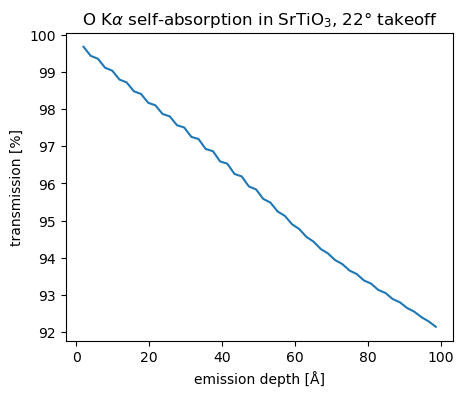

In [19]:
thin_atoms = read("../walkthrough/data/srtio3_100.cif")
thin_slice_thickness = thin_atoms.cell[2, 2] / 2
thin_atoms *= (1, 1, 25)

# One exit plane per slice, so the result is resolved by emission depth.
thin_potential = abtem.Potential(
    thin_atoms, gpts=32, slice_thickness=thin_slice_thickness, exit_planes=1, device="cpu"
)

thin_probe = abtem.Probe(semiangle_cutoff=25, energy=100e3, device="cpu")
thin_probe.grid.match(thin_potential)

O_abs_transitions = abtem.SubshellTransitions(
    Z=8, n=1, l=0, xc="PBE", order=1, epsilon=abtem.EnergyIntegral(stop=4 * 543.1, num=4)
)
O_abs_transition_potentials = O_abs_transitions.get_transition_potentials(
    extent=thin_potential.extent, gpts=thin_potential.gpts, energy=100e3
)

# xraydb only has densities for elements and a handful of named compounds, not
# arbitrary formulas, so a compound like SrTiO3 needs its density given explicitly.
absorption = SpecimenAbsorption("SrTiO3", density=5.11, takeoff_angle=22.0)

no_absorption = thin_probe.transition_potential_scan(
    thin_potential, O_abs_transition_potentials, scan=(0, 0),
    detectors=abtem.XrayDetector(solid_angle=0.7),
    double_channel=False,
).compute()
with_absorption = thin_probe.transition_potential_scan(
    thin_potential, O_abs_transition_potentials, scan=(0, 0),
    detectors=abtem.XrayDetector(solid_angle=0.7, absorption=absorption),
    double_channel=False,
).compute()

depths = np.arange(1, len(no_absorption.array)) * thin_slice_thickness
transmission = (
    np.asarray(with_absorption.array)[1:] / np.asarray(no_absorption.array)[1:]
)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(depths, transmission * 100)
ax.set_xlabel("emission depth [Å]")
ax.set_ylabel("transmission [%]")
ax.set_title("O K$\\alpha$ self-absorption in SrTiO$_3$, 22° takeoff");

print(f"transmission near the entrance surface: {transmission[0]:.1%}")
print(f"transmission from the far side ({depths[-1]:.0f} A deep): {transmission[-1]:.1%}")

X-rays generated near the entrance surface barely notice the specimen; by the far side of this ~100 Å column, self-absorption alone accounts for several percent of the signal, on top of the collection-efficiency terms already folded into `to_counts` above. For a thicker specimen, or an even softer line, the effect is correspondingly larger — worth checking whenever the measurement in hand isn't reliably from a thin region.

This cell's single-unit-cell lateral extent is well below the inelastic delocalisation length, so it triggers the same convergence warning covered below — harmless here, since both curves share the identical, equally-truncated transition potential and the *ratio* between them cancels that systematic error almost exactly.

### L and M edges: combining subshells

A vacancy in an L1 (2s) state largely migrates to L2/L3 by Coster-Kronig transitions before it radiates, so an L-family measurement needs the 2s and 2p ionisation combined — each weighted by its own probability, not simply added after conversion. `to_counts_from_subshells` does this. We demonstrate it on silver, computing the L1 and L23 ionisation separately and combining them.

```{note}
L23 (a p subshell, $\ell=1$) comes out several times stronger than L1 (an s subshell, $\ell=0$) below — mostly real physics (more final states, a larger cross-section per electron), but do not treat the printed ratio as universal: an early version of `SubshellTransitions` over-counted every L or M edge's orbital degeneracy by exactly $(2\ell+1)$ — 3x too large for a p subshell, 5x for a d subshell — invisible for any K edge (where $2\ell+1=1$), and only caught once an L edge was checked directly against an independent tabulation. It is fixed as of this abTEM version; every L- or M-edge number on this page already reflects the fix.
```

L23 / L1 ionisation ratio: 5.6


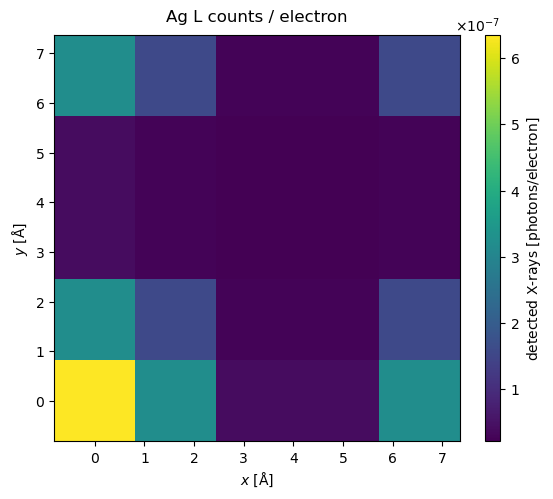

In [20]:
atoms = ase.build.bulk("Ag", cubic=True) * (2, 2, 4)
potential = abtem.Potential(atoms, gpts=64, slice_thickness=1.0, exit_planes=1)
probe = abtem.Probe(energy=100e3, semiangle_cutoff=25)
probe.grid.match(potential)
scan = abtem.GridScan(start=(0, 0), end=(potential.extent[0], potential.extent[1]), sampling=2.0)

l1 = abtem.SubshellTransitions(Z=47, n=2, l=0, epsilon=abtem.EnergyIntegral(stop=4 * 3806.0, num=8))
l1_transitions = l1.get_transition_potentials(extent=potential.extent, gpts=potential.gpts, energy=100e3)
l1_map = probe.ionization_scan(potential, l1_transitions, scan=scan).compute()

l23 = abtem.SubshellTransitions(Z=47, n=2, l=1, epsilon=abtem.EnergyIntegral(stop=4 * 3524.0, num=8))
l23_transitions = l23.get_transition_potentials(extent=potential.extent, gpts=potential.gpts, energy=100e3)
l23_map = probe.ionization_scan(potential, l23_transitions, scan=scan).compute()

print(f"L23 / L1 ionisation ratio: {float(np.asarray(l23_map.array).max() / np.asarray(l1_map.array).max()):.1f}")

detector = abtem.XrayDetector(solid_angle=0.7)
l_counts = detector.to_counts_from_subshells({(2, 0): l1_map, (2, 1): l23_map}, "Ag")

l_counts[-1].show(cbar=True, title="Ag L counts / electron");

### PRISM and absolute cross-sections

`ionization_scan` is also available on `SMatrix`, giving the same linear-scaling benefit as `SMatrix.transition_potential_scan` did for EELS. At `interpolation=1` it reproduces `Probe.ionization_scan` up to floating-point noise; higher interpolation trades a small amount of accuracy for speed.

In [21]:
s_matrix = abtem.SMatrix(potential=potential, energy=100e3, semiangle_cutoff=25, interpolation=2, device="cpu")
prism_ionization = s_matrix.ionization_scan(l23_transitions, scan=scan).compute()
prism_ionization.array.shape

(18, 5, 5)

A plane wave of unit intensity gives the cross-section per unit area directly, which is useful for comparing against tabulated or literature values without a probe or a scan at all.

In [22]:
plane_wave = abtem.PlaneWave(energy=100e3)
plane_wave.grid.match(potential)
sigma = plane_wave.ionization_multislice(potential, l23_transitions).compute()
print(f"Ag L23 cross-section: {float(np.asarray(sigma.array).max()):.3e} Å² / atom")

Ag L23 cross-section: 7.194e+02 Å² / atom


### The atomic data on its own

The tables behind `XrayDetector` — fluorescence yields, branching ratios, emission line energies — are also available directly from `abtem.inelastic.xray_data`, independent of any simulation.

In [23]:
print(fluorescence_yield("Cu", 1, 0))
print(emission_lines("Cu", 1, 0)["Ka1"])

0.441091
EmissionLine(name='Ka1', energy=8046.3, intensity=0.25455719166652324, initial_level='K', final_level='L3')


### Convergence: two parameters that bite silently

Two simulation parameters affect EDX (and EELS) accuracy in ways that don't announce themselves as clearly as, say, real-space sampling does.

**The cell must be large enough.** An inelastic scattering event is delocalised over a length set by the beam energy and the energy loss, $b \sim \hbar v / \Delta E$ — a cell smaller than a few times this length truncates the transition potential and *overestimates* the cross-section, because the potential's tails are cut off along with some of its normalisation. abTEM warns when this happens; we already saw the warning fire for the small demo grids used in the [previous tutorial](tutorials:core_loss). Below, we track a carbon K-edge cross-section as the cell grows.

In [24]:
import warnings

results = []
for reps in (2, 4, 6, 10):
    atoms = ase.build.bulk("C", cubic=True) * (reps, reps, 2)
    potential = abtem.Potential(atoms, gpts=24 * reps, slice_thickness=1.78, exit_planes=1)
    probe = abtem.Probe(energy=300e3, semiangle_cutoff=25)
    probe.grid.match(potential)
    center = potential.extent[0] / 2, potential.extent[1] / 2
    sites = atoms[np.linalg.norm(atoms.positions[:, :2] - np.array(center), axis=1) < 0.1]

    subshell = abtem.SubshellTransitions(Z=6, n=1, l=0, epsilon=abtem.EnergyIntegral(stop=4 * 284.0, num=4))
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        transitions = subshell.get_transition_potentials(
            extent=potential.extent, gpts=potential.gpts, energy=300e3
        )
        result = probe.ionization_scan(potential, transitions, scan=center, sites=sites).compute()
        warned = any("delocalis" in str(w.message) for w in caught)

    results.append((potential.extent[0], warned, float(np.asarray(result.array).max())))

converged = results[-1][2]
for extent, warned, value in results:
    print(f"extent={extent:5.1f} A  warned={warned!s:5}  value={value:.4e}  ({(value / converged - 1) * 100:+.1f} % vs. converged)")

extent=  7.1 A  warned=True   value=1.7039e-04  (+4.1 % vs. converged)
extent= 14.3 A  warned=True   value=1.6569e-04  (+1.2 % vs. converged)
extent= 21.4 A  warned=True   value=1.6449e-04  (+0.5 % vs. converged)
extent= 35.7 A  warned=False  value=1.6367e-04  (+0.0 % vs. converged)


The smallest cell here already warns, and its cross-section is measurably high; a well-converged cell for a carbon K edge at higher beam energy needs to be even larger than this, up to tens of percent high for an 8 Å cell at 300 keV in the validated case documented alongside this release. When in doubt, increase the extent until the result stops moving.

**`order=1` under-counts.** Restricting to dipole transitions ($\ell' = \ell \pm 1$) misses the quadrupole and higher channels, which is a bigger effect for higher-Z edges. We compare `order=1` against `order=2` for the Si K edge used above.

In [25]:
atoms = ase.build.bulk("Si", cubic=True) * (2, 2, 4)
potential = abtem.Potential(atoms, gpts=64, slice_thickness=1.36, exit_planes=1)
probe = abtem.Probe(energy=100e3, semiangle_cutoff=25)
probe.grid.match(potential)
center = potential.extent[0] / 2, potential.extent[1] / 2
sites = atoms[np.linalg.norm(atoms.positions[:, :2] - np.array(center), axis=1) < 0.1]

values = {}
for order in (1, 2):
    subshell = abtem.SubshellTransitions(
        Z=14, n=1, l=0, order=order, epsilon=abtem.EnergyIntegral(stop=4 * 1839.0, num=4)
    )
    transitions = subshell.get_transition_potentials(
        extent=potential.extent, gpts=potential.gpts, energy=100e3
    )
    result = probe.ionization_scan(potential, transitions, scan=center, sites=sites)
    values[order] = float(np.asarray(result.compute().array).max())

print(f"order=1: {values[1]:.4e}")
print(f"order=2: {values[2]:.4e}")
print(f"order=1 undercounts by {(1 - values[1] / values[2]) * 100:.1f} % here")

order=1: 8.7693e-05
order=2: 9.2157e-05
order=1 undercounts by 4.8 % here


The gap for a light K edge like this one is modest, and grows for heavier edges: a direct check against an independent tabulation (below) found `order=1` alone plateaus at only ~85 % of its `order=3` value for a Cu K edge, regardless of how well the energy integral is converged — a real, physics-level under-count, not a rounding effect. Check `order=2` or higher whenever an edge matters quantitatively, especially for anything past the first few rows of the periodic table.

### How much to trust the absolute scale

abTEM's core-loss cross-sections have been checked against three independent sources, each covering a different weight class of edge.

**Light and medium K edges**, via the Bethe slope compared to $M^2$ from tabulated photoabsorption data: silicon lands at 0.90 of the independent value (1.02 with `order=2`), carbon at 1.41 with a converged cell.

**A heavy edge**, via a direct comparison against Bote & Salvat's (2008) tabulated ionisation cross-sections — the only route available once the Bethe-slope method's relativistic assumptions break down. For Cu K at 300 keV, abTEM's *default* settings (`order=1`, a modest `EnergyIntegral`) come out ~19 % low; converging both `order` (to 3) and the energy-integral cutoff removes that shortfall and leaves a real, physically-expected residual: abTEM's plane-wave Born treatment lands ~8–10 % *above* Bote-Salvat's distorted-wave value, the textbook direction for that approximation gap. Net: treat a heavy edge's absolute cross-section as good to no better than ~20 % at default settings, tightening only once `order` and the energy integral are both converged for the beam energy in use.

**A published measurement**: reproducing all four edges (Sr K, Ti K, Sr L$_{23}$, O K) from Chen et al.'s STEM-EDX study of SrTiO$_3$ (*Ultramicroscopy* 168 (2016), 7–16) lands in one common band of roughly 1.05–1.6$\times$ their reported values, once detector efficiency, specimen self-absorption and the correct atom count per unit cell are accounted for. The leading candidate for that residual is the paper's own effective, geometry-reduced solid angle against the flat nominal value used here — not yet checked quantitatively. Reproducing this comparison for an L edge for the first time is in fact what surfaced the orbital-degeneracy bug noted above: before the fix, Sr L$_{23}$ alone was 3$\times$ too high, next to the other three edges' consistent ~1.05–1.6$\times$.

This matters for how to read an EDX (or EELS) simulation: **relative contrast — comparing two positions, two edges, two thicknesses in the same simulation — is reliable throughout**, since a fixed multiplicative gap cancels in a ratio. Treating an absolute intensity as quantitative needs the edge to be light-to-medium and `order`/`EnergyIntegral`-converged, or an explicit correction factor from one of the checks above for anything heavier.

### A note on speed

For EDX **alone**, the effective-potential route (`ionization_scan`) is dramatically cheaper than the scattered-wave route (`transition_potential_scan`) — 1.8 to 46x faster depending on problem size, since it needs no scattered waves at all. If EELS is not wanted, use `ionization_scan` directly rather than the joint pass below.

## EELS and EDX from one pass

The elastic multislice and the scattered waves in `transition_potential_scan` are shared across detectors, so an angular detector (EELS) and `XrayDetector` (EDX) can be filled in the same pass — `XrayDetector` is itself a detector, so it goes straight into `detectors=`, exactly like the EELS-only case earlier on this page. Validation in the release notes puts the overhead of adding EDX to an existing EELS run as low as +17 %, against paying for the whole multislice pass twice if run separately — but as the timing below shows, how much it actually costs depends heavily on the problem size and the detector combination, so treat that figure as a best case rather than a rule.

We use the same SrTiO$_3$ specimen, probe and scan as the atomic-resolution maps above, so the result is directly comparable to the EELS-only O K scan timed there.

EELS-only O K scan (from above): 75 s
Joint EELS+EDX O K scan:         1168 s


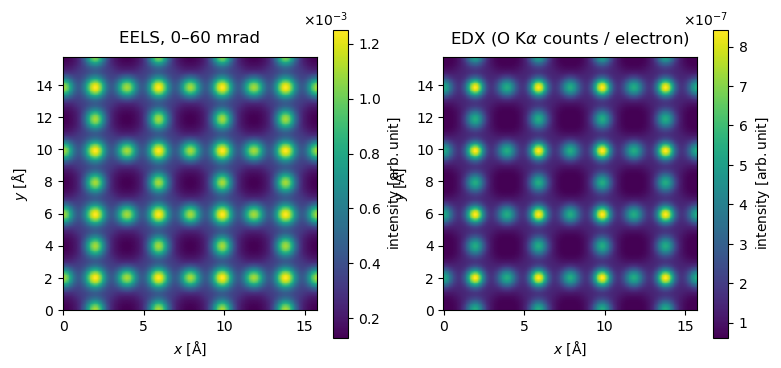

In [26]:
atoms = read("../walkthrough/data/srtio3_100.cif")
slice_thickness = atoms.cell[2, 2] / 2
atoms *= (4, 4, 25)
potential = abtem.Potential(atoms, gpts=256, slice_thickness=slice_thickness, device="cpu")

probe = abtem.Probe(semiangle_cutoff=25, energy=100e3, device="cpu")
probe.grid.match(potential)

scan = abtem.GridScan(
    start=(0, 0), end=(1 / 4, 1 / 4), fractional=True, potential=potential, endpoint=False
)

O_joint_transitions = abtem.SubshellTransitions(
    Z=8, n=1, l=0, xc="PBE", order=1, epsilon=abtem.EnergyIntegral(stop=4 * 543.1, num=8)
)
O_joint_transition_potentials = O_joint_transitions.get_transition_potentials(
    extent=potential.extent, gpts=potential.gpts, energy=100e3
).build()

t0 = time.time()
eels, edx_counts = probe.transition_potential_scan(
    potential, O_joint_transition_potentials, scan=scan,
    detectors=[abtem.AnnularDetector(inner=0.0, outer=60.0), abtem.XrayDetector(solid_angle=0.7)],
    double_channel=False, max_batch=40, threshold=0.95,
)
eels = eels.compute(scheduler="threads", num_workers=6)
edx_counts = edx_counts.compute(scheduler="threads", num_workers=6)
joint_seconds = time.time() - t0

print(f"EELS-only O K scan (from above): {eels_only_seconds:.0f} s")
print(f"Joint EELS+EDX O K scan:         {joint_seconds:.0f} s")

eels_map = eels.tile(repetitions=(4, 4)).interpolate(sampling=0.05)
edx_map = edx_counts.tile(repetitions=(4, 4)).interpolate(sampling=0.05)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
eels_map.show(ax=axes[0], cbar=True, title="EELS, 0–60 mrad");
edx_map.show(ax=axes[1], cbar=True, title="EDX (O K$\\alpha$ counts / electron)");

`eels` and `edx_counts` are computed from the same elastic wave functions and the same scattered waves: nothing about the specimen or the probe was simulated twice, and the two maps above line up pixel for pixel. Whether that shared cost is worth it against running `ionization_scan` and `transition_potential_scan` separately depends entirely on the printed timings — compare them for your own problem size before committing to the joint pass.

```{note}
Earlier abTEM versions needed a workaround here: `XrayDetector`'s emission-line lookups queried [xraydb](https://github.com/xraypy/XrayDB)'s SQLite-backed tables directly, which was not safe to do concurrently from multiple threads inside a scan at this scale. That is fixed as of this release — the lookups are cached at the source, so the pattern above is safe with any thread count.
```